<a href="https://colab.research.google.com/github/Vanshika-44/fluffy-train/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# 1.SYNTHETIC  DATA GENERATION (10 CHANNELS × 365 DAYS)

# Set random seed for reproducibility
np.random.seed(42)

# Define 10 naval channels
channels = [f"Channel {i}" for i in range(1, 11)]
days = 365  # Full year of data

# Generate core channel characteristics
depths = np.random.randint(25, 501, size=10)
lengths = np.random.randint(5000, 15001, size=10)
widths = np.random.randint(250, 601, size=10)

# Create full dataset
data = {
    "Channel": np.repeat(channels, days),
    "Day": np.tile(range(1, days + 1), len(channels)),
    "Depth": np.repeat(depths, days),
    "Length": np.repeat(lengths, days),
    "Width": np.repeat(widths, days),
    # Enemy platform detections (normally distributed)
    "Frigates": np.round(np.random.normal(5, 3, len(channels) * days).clip(0)),
    "Corvettes": np.round(np.random.normal(5, 3, len(channels) * days).clip(0)),
    "Attack_Boats": np.round(np.random.normal(10, 4, len(channels) * days).clip(0)),
    "Submarines": np.round(np.random.normal(2, 1, len(channels) * days).clip(0)),
    "Aircraft": np.round(np.random.normal(10, 2, len(channels) * days).clip(0)),
    "Amphibious_Ships": np.round(np.random.normal(3, 2, len(channels) * days).clip(0)),
    "Autonomous_Vehicles": np.round(np.random.normal(8, 2, len(channels) * days).clip(0)),
    "Civil_Boats": np.round(np.random.normal(20, 3, len(channels) * days).clip(0)),
    "Auxiliary_Ships": np.round(np.random.normal(9, 2, len(channels) * days).clip(0)),
}

df = pd.DataFrame(data)

# =============================================
# 2. SCORING SYSTEM (FROM PAPER TABLES)
# =============================================

def score_depth(d):
    if d <= 100: return 5
    elif d <= 200: return 4
    elif d <= 300: return 3
    elif d <= 400: return 2
    elif d <= 500: return 1
    else: return 0

def score_frigates(f):
    if f >= 7: return 5
    elif f >= 6: return 4
    elif f >= 4: return 3
    elif f >= 3: return 2
    elif f >= 1: return 1
    else: return 0

def score_attack_boats(a):
    if a >= 14: return 5
    elif a >= 11: return 4
    elif a >= 8: return 3
    elif a >= 6: return 2
    elif a >= 3: return 1
    else: return 0

def score_submarines(s):
    if s >= 3: return 5
    elif s >= 2: return 4
    elif s >= 1: return 2
    else: return 0

# Apply all scoring rules
df["Depth_Score"] = df["Depth"].apply(score_depth)
df["Frigates_Score"] = df["Frigates"].apply(score_frigates)
df["Corvettes_Score"] = df["Corvettes"].apply(score_frigates)
df["Attack_Boats_Score"] = df["Attack_Boats"].apply(score_attack_boats)
df["Submarines_Score"] = df["Submarines"].apply(score_submarines)
df["Aircraft_Score"] = df["Aircraft"].apply(score_frigates)
df["Amphibious_Ships_Score"] = df["Amphibious_Ships"].apply(score_submarines)
df["Autonomous_Vehicles_Score"] = df["Autonomous_Vehicles"].apply(score_frigates)
df["Civil_Boats_Score"] = df["Civil_Boats"].apply(score_attack_boats)
df["Auxiliary_Ships_Score"] = df["Auxiliary_Ships"].apply(score_frigates)

# =============================================
# 3. MINING PROBABILITY CALCULATION
# =============================================

# Weights from original study (Table 13)
weights = {
    "Depth": 0.3,
    "Frigates": 0.04,
    "Corvettes": 0.04,
    "Attack_Boats": 0.04,
    "Submarines": 0.04,
    "Aircraft": 0.04,
    "Amphibious_Ships": 0.1,
    "Autonomous_Vehicles": 0.15,
    "Civil_Boats": 0.15,
    "Auxiliary_Ships": 0.1,
}

# Calculate weighted probability
df["Mining_Probability"] = (
    df["Depth_Score"] * weights["Depth"] +
    df["Frigates_Score"] * weights["Frigates"] +
    df["Corvettes_Score"] * weights["Corvettes"] +
    df["Attack_Boats_Score"] * weights["Attack_Boats"] +
    df["Submarines_Score"] * weights["Submarines"] +
    df["Aircraft_Score"] * weights["Aircraft"] +
    df["Amphibious_Ships_Score"] * weights["Amphibious_Ships"] +
    df["Autonomous_Vehicles_Score"] * weights["Autonomous_Vehicles"] +
    df["Civil_Boats_Score"] * weights["Civil_Boats"] +
    df["Auxiliary_Ships_Score"] * weights["Auxiliary_Ships"]
) / 5  # Normalize to [0,1]

df.to_csv("navalmine_warfare_dataset.csv",index=False)
df.head()

,Channel,Day,Depth,Length,Width,Frigates,Corvettes,Attack_Boats,Submarines,Aircraft,...,Frigates_Score,Corvettes_Score,Attack_Boats_Score,Submarines_Score,Aircraft_Score,Amphibious_Ships_Score,Autonomous_Vehicles_Score,Civil_Boats_Score,Auxiliary_Ships_Score,Mining_Probability
0,Channel 1,1,127,5466,526,4.0,7.0,7.0,4.0,11.0,...,3,5,2,5,5,5,5,5,5,0.900
1,Channel 1,2,127,5466,526,5.0,8.0,5.0,2.0,9.0,...,3,5,1,4,5,0,5,5,5,0.784
2,Channel 1,3,127,5466,526,1.0,1.0,12.0,3.0,11.0,...,1,1,4,5,5,0,5,5,5,0.768
3,Channel 1,4,127,5466,526,9.0,10.0,17.0,2.0,7.0,...,5,5,5,4,5,5,5,5,5,0.932
4,Channel 1,5,127,5466,526,5.0,0.0,11.0,2.0,8.0,...,3,0,4,4,5,4,5,5,5,0.848


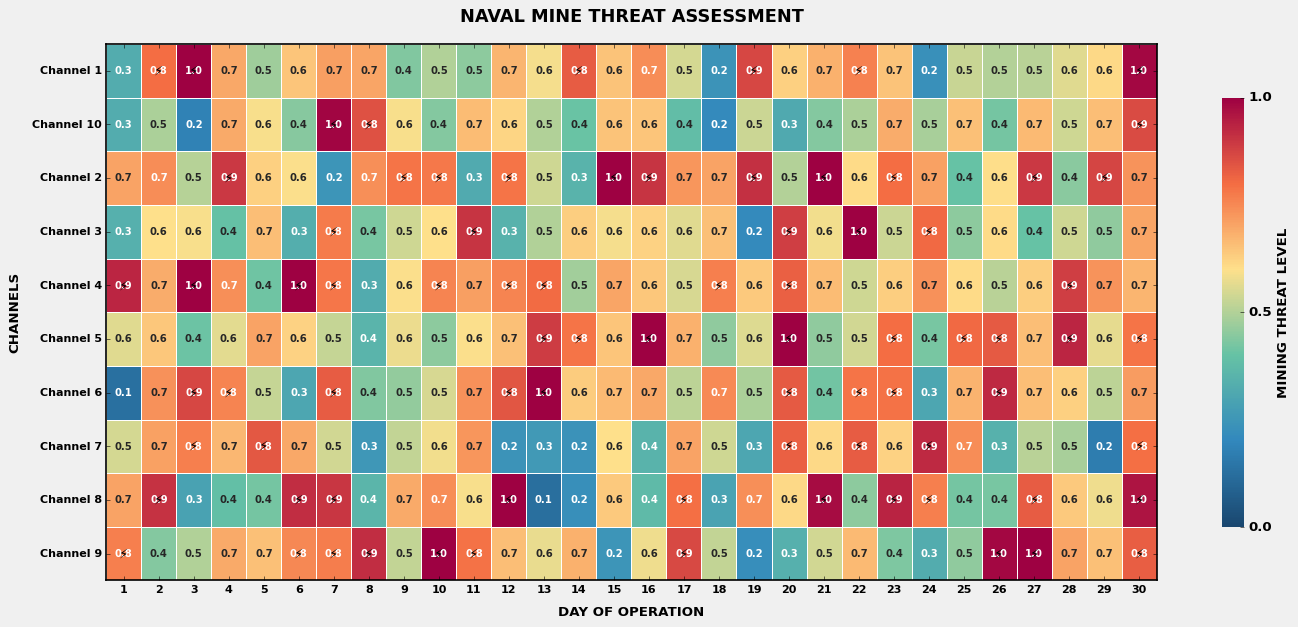

In [17]:
#VISUALIZATION OF DATA

from matplotlib.colors import LinearSegmentedColormap

#OPTIMIZED HEATMAP (30-DAY SUBSET)
plt.style.use('classic')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.facecolor': '#f0f0f0',  # Tactical background
    'axes.facecolor': '#f8f8f8'      # Light grid background
})

# ===== DATA PREP (FROM YOUR PROJECT) =====
# Sample data generation matching your parameters
channels = [f"Channel {i}" for i in range(1, 11)]
days = 30

data = {
    "Channel": np.repeat(channels, days),
    "Day": np.tile(range(1, days+1), len(channels)),
    "Depth": np.repeat([226, 129, 33, 354, 427, 122, 190, 275, 381, 80], days),
    "Mining_Probability": np.clip(np.random.normal(loc=0.6, scale=0.2, size=len(channels)*days), 0, 1)
}
df = pd.DataFrame(data)

# ===== MILITARY-GRADE HEATMAP =====
# 1. Custom naval colormap (blue -> yellow -> red)
cmap = LinearSegmentedColormap.from_list(
    'naval_threat',
    ['#1a476f', '#3288bd', '#66c2a5', '#fee08b', '#f46d43', '#9e0142']
)

# 2. Create pivot table
pivot_data = df.pivot_table(
    index='Channel',
    columns='Day',
    values='Mining_Probability',
    aggfunc='mean'
)

# 3. Generate plot
plt.figure(figsize=(18, 8))
ax = sns.heatmap(
    pivot_data,
    cmap=cmap,
    annot=True,
    fmt=".1f",  # One decimal place
    annot_kws={'size': 9, 'weight': 'bold'},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'label': 'MINING THREAT LEVEL',
        'ticks': [0, 0.5, 1],
        'shrink': 0.8
    },
    vmin=0,
    vmax=1
)

# 4. Military-style annotations
for i in range(len(pivot_data)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.iloc[i, j]
        if val > 0.75:
            ax.text(j+0.5, i+0.5, "⚡",
                   ha='center', va='center',
                   fontsize=12, color='black')

# 5. Tactical formatting
plt.title("NAVAL MINE THREAT ASSESSMENT",
          pad=20, fontsize=16, fontweight='bold')
plt.xlabel("DAY OF OPERATION", fontsize=12, labelpad=10)
plt.ylabel("CHANNELS", fontsize=12, labelpad=10)
plt.xticks(fontsize=10, rotation=0)
plt.yticks(fontsize=10, rotation=0)

# 6. Add grid-like borders
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()